In [1]:
import yfinance as yf
import pandas as pd

tickers = ["AAPL", "MSFT", "GOOGL", "RELIANCE.NS", "TCS.NS"]
data = yf.download(tickers, start="2020-01-01")  # adjust date if you want
data.head()


[*********************100%***********************]  5 of 5 completed


Price           Close                                                  \
Ticker           AAPL      GOOGL        MSFT RELIANCE.NS       TCS.NS   
Date                                                                    
2020-01-01        NaN        NaN         NaN  675.324219  1866.113647   
2020-01-02  72.400520  67.920807  152.505676  686.821228  1857.547852   
2020-01-03  71.696632  67.565498  150.606735  687.648804  1894.567505   
2020-01-06  72.267937  69.366386  150.996017  671.700684  1894.395386   
2020-01-07  71.928047  69.232399  149.619247  682.034485  1899.043945   

Price            High                                                  ...  \
Ticker           AAPL      GOOGL        MSFT RELIANCE.NS       TCS.NS  ...   
Date                                                                   ...   
2020-01-01        NaN        NaN         NaN  683.152914  1880.146350  ...   
2020-01-02  72.460784  67.920807  152.610120  689.348791  1876.746243  ...   
2020-01-03  72.455950  68.172416  151.869547  689.661895  1913.808988  ...   
2020-01-06  72.306506  69.391693  151.062488  683.510767  1916.348660  ...   
2020-01-07  72.533087  69.648755  151.603660  686.463273  1906.619807  ...   

Price            Open                                                  \
Ticker           AAPL      GOOGL        MSFT RELIANCE.NS       TCS.NS   
Date                                                                    
2020-01-01        NaN        NaN         NaN  679.081997  1866.457928   
2020-01-02  71.409785  66.914911  150.758634  676.397899  1876.746243   
2020-01-03  71.629138  66.894573  150.321902  685.792252  1863.015138   
2020-01-06  70.819208  67.074696  149.144532  679.976719  1898.312581   
2020-01-07  72.277571  69.497895  151.271350  679.529260  1894.437979   

Price            Volume                                                 
Ticker             AAPL       GOOGL        MSFT RELIANCE.NS     TCS.NS  
Date                                                                    
2020-01-01          NaN         NaN         NaN  14004468.0  1354908.0  
2020-01-02  135480400.0  27278000.0  22622100.0  17710316.0  2380752.0  
2020-01-03  146322800.0  23408000.0  21116200.0  20984698.0  4655761.0  
2020-01-06  118387200.0  46768000.0  20813700.0  24519177.0  3023209.0  
2020-01-07  108872000.0  34330000.0  21634100.0  16683622.0  2429317.0  

[5 rows x 25 columns]

In [2]:
close = data["Close"].dropna()
close.head()


Ticker,AAPL,GOOGL,MSFT,RELIANCE.NS,TCS.NS
Date,,,,,
2020-01-02,72.400520,67.920807,152.505676,686.821228,1857.547852
2020-01-03,71.696632,67.565498,150.606735,687.648804,1894.567505
2020-01-06,72.267937,69.366386,150.996017,671.700684,1894.395386
2020-01-07,71.928047,69.232399,149.619247,682.034485,1899.043945
2020-01-08,73.085106,69.725174,152.002457,676.912354,1941.572754


In [3]:
returns = close.pct_change().dropna()
returns.head()


Ticker,AAPL,GOOGL,MSFT,RELIANCE.NS,TCS.NS
Date,,,,,
2020-01-03,-0.009722,-0.005231,-0.012452,0.001205,0.019929
2020-01-06,0.007968,0.026654,0.002585,-0.023192,-0.000091
2020-01-07,-0.004703,-0.001932,-0.009118,0.015385,0.002454
2020-01-08,0.016086,0.007118,0.015928,-0.007510,0.022395
2020-01-09,0.021241,0.010498,0.012493,0.023031,-0.018135


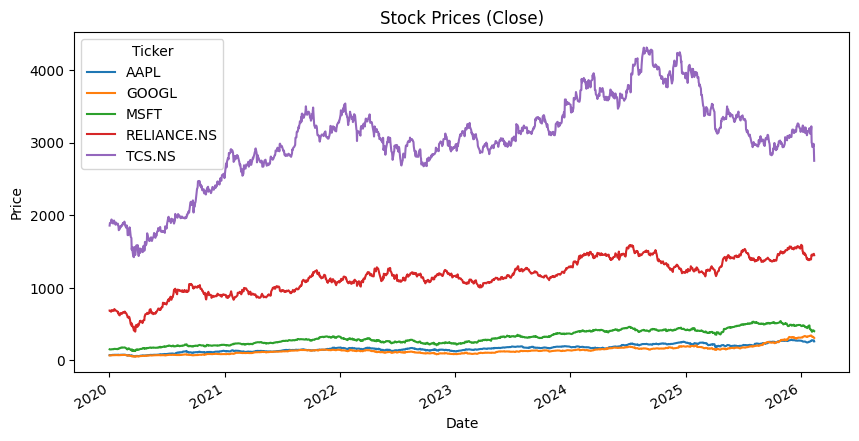

<Figure size 640x480 with 0 Axes>

In [4]:
import matplotlib.pyplot as plt

close.plot(figsize=(10,5))
plt.title("Stock Prices (Close)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

plt.savefig("visualizations/price_trend.png", dpi=300, bbox_inches="tight")


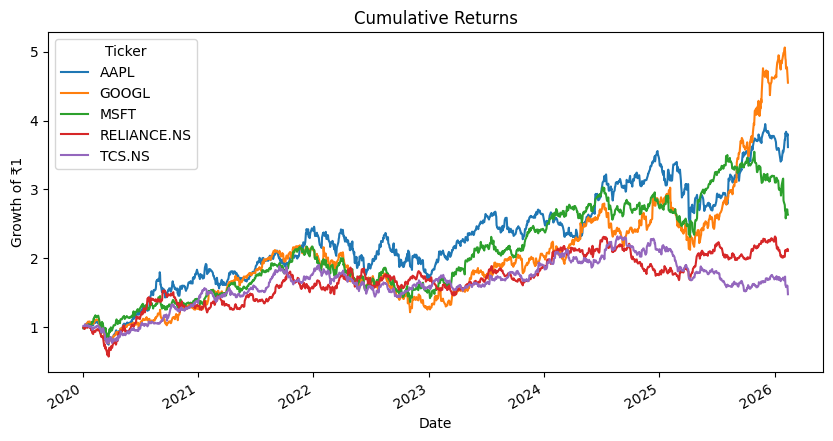

<Figure size 640x480 with 0 Axes>

In [5]:
cum_returns = (1 + returns).cumprod()

cum_returns.plot(figsize=(10,5))
plt.title("Cumulative Returns")
plt.xlabel("Date")
plt.ylabel("Growth of ₹1")
plt.show()

plt.savefig("visualizations/cumulative_returns.png", dpi=300, bbox_inches="tight")


In [6]:
risk = pd.DataFrame()
risk["Annual Return"] = returns.mean() * 252
risk["Annual Volatility"] = returns.std() * 252**0.5
risk["Sharpe (rf=0)"] = risk["Annual Return"] / risk["Annual Volatility"]

risk.sort_values("Sharpe (rf=0)", ascending=False)


,Annual Return,Annual Volatility,Sharpe (rf=0)
Ticker,,,
GOOGL,0.314787,0.328773,0.957459
AAPL,0.273141,0.322945,0.845781
MSFT,0.213163,0.304689,0.699610
RELIANCE.NS,0.169099,0.285642,0.591997
TCS.NS,0.097701,0.245781,0.397511


In [7]:
risk.to_csv("datasets/risk_metrics.csv", index=True)


In [8]:
def max_drawdown(series):
    cum = (1 + series).cumprod()
    peak = cum.cummax()
    dd = (cum - peak) / peak
    return dd.min()

mdd = returns.apply(max_drawdown).sort_values()
mdd


Ticker
GOOGL         -0.443200
RELIANCE.NS   -0.440829
MSFT          -0.370439
TCS.NS        -0.362160
AAPL          -0.333605
dtype: float64

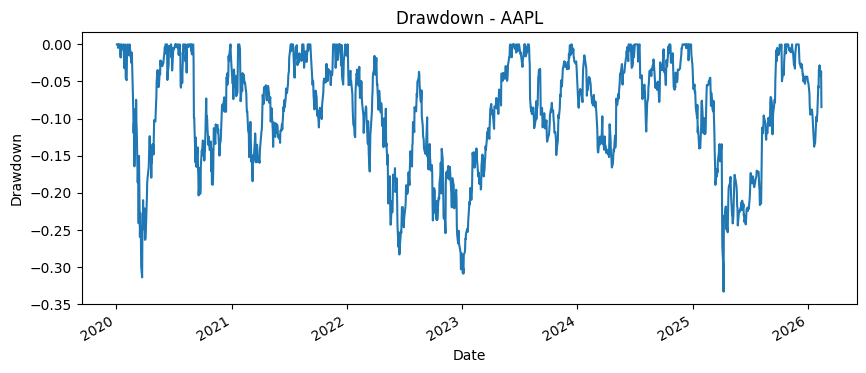

<Figure size 640x480 with 0 Axes>

In [9]:
ticker = "AAPL"
cum = (1 + returns[ticker]).cumprod()
peak = cum.cummax()
drawdown = (cum - peak) / peak

drawdown.plot(figsize=(10,4))
plt.title(f"Drawdown - {ticker}")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.show()

plt.savefig("visualizations/drawdown_aapl.png", dpi=300, bbox_inches="tight")


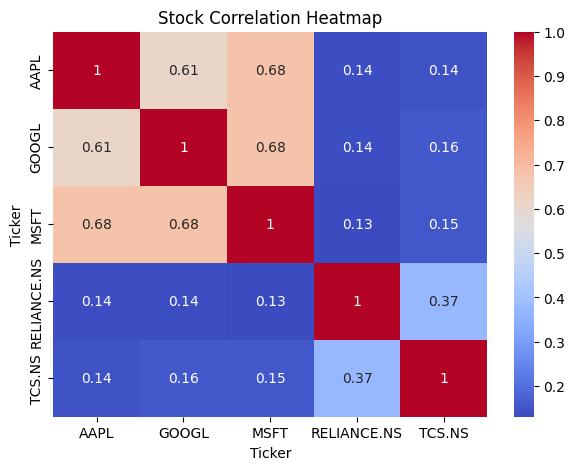

<Figure size 640x480 with 0 Axes>

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
sns.heatmap(returns.corr(), annot=True, cmap="coolwarm")
plt.title("Stock Correlation Heatmap")
plt.show()

plt.savefig("visualizations/correlation_heatmap.png", dpi=300, bbox_inches="tight")


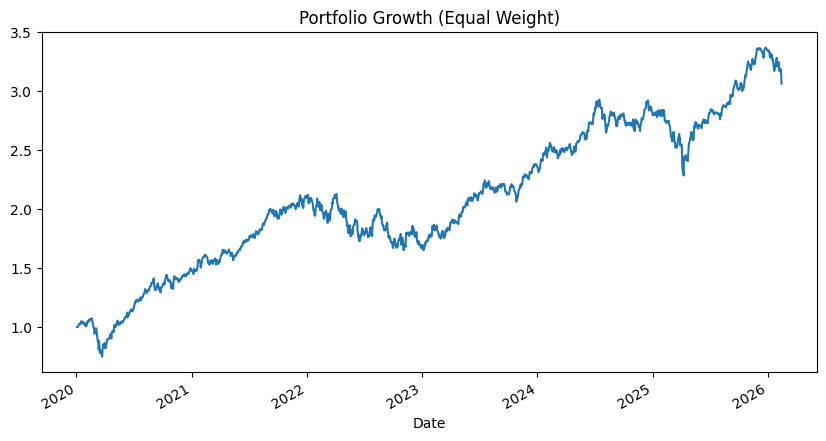

<Figure size 640x480 with 0 Axes>

In [11]:
weights = [1/len(returns.columns)] * len(returns.columns)

portfolio_return = (returns * weights).sum(axis=1)

cum_portfolio = (1 + portfolio_return).cumprod()

cum_portfolio.plot(figsize=(10,5))
plt.title("Portfolio Growth (Equal Weight)")
plt.show()

plt.savefig("visualizations/portfolio_growth.png", dpi=300, bbox_inches="tight")


In [12]:
annual_return = portfolio_return.mean()*252
annual_vol = portfolio_return.std()*252**0.5
sharpe = annual_return/annual_vol

print("Portfolio Sharpe Ratio:", sharpe)


Portfolio Sharpe Ratio: 1.0451641323934646


In [13]:
stock = returns['AAPL'].copy()

df_ml = pd.DataFrame()
df_ml['Return'] = stock
df_ml['Lag1'] = stock.shift(1)
df_ml['Lag2'] = stock.shift(2)
df_ml['Lag3'] = stock.shift(3)

df_ml['Target'] = (df_ml['Return'] > 0).astype(int)
df_ml = df_ml.dropna()


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X = df_ml[['Lag1','Lag2','Lag3']]
y = df_ml['Target']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

model = RandomForestClassifier()
model.fit(X_train,y_train)

pred = model.predict(X_test)
print("Prediction Accuracy:", accuracy_score(y_test,pred))


Prediction Accuracy: 0.5255972696245734


Key Findings:
- Some stocks highly correlated (less diversification)
- Portfolio reduced risk compared to single stock
- Tech stocks showed highest long-term growth
- Market direction difficult to predict accurately

Finance Insight:
Diversification improves stability but reduces extreme gains.

Recommendation:
Investors should diversify across sectors rather than single stock.
